### Program Name: Exponential Growth Model: Numerical Solution
#### Author: C.D. Wentworth + Johang Hernandez
*version: 3.18.2026.1*

> Summary: Basic script for solving a dynamical system representing
         exponential growth. A numerical integration technique is
         used.

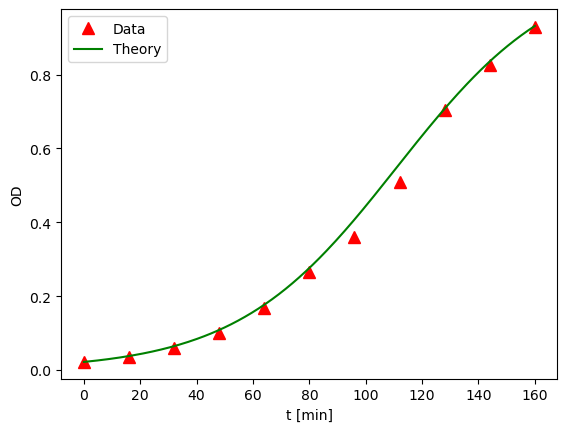

In [6]:
import scipy.integrate as si
import numpy as np
import matplotlib.pylab as plt

def f(t,y,r, M):
    """
    y = a list that contains the system state
    t = the time for which the right-hand-side of the system equations
        is to be calculated.
    r = a parameter needed for the model
    M=
    """



#   Unpack the state of the system
    y0 = y[0] # cell density 

#   Calculate the rates of change (the derivatives)
    dy0dt = r*y0*(1 - y0/M)

    return [dy0dt]

# Main Program

# Read in data
cols = np.loadtxt("V_natriegensGrowthData.txt", skiprows=4)
timeData = cols[:,0]
od_data= cols[:,2]

# Define the initial conditions
N0 = [0.022]

# Define the time grid
t = np.linspace(0,160,200)

# Define the model parameters
r = 0.035
M = 1.1
p = (r,M)

# Solve the DE
sol = si.solve_ivp(f,(0,160),N0,t_eval=t,args=p)
N = sol.y[0]

# Plot the data
plt.plot(timeData,od_data,linestyle='',marker='^',markersize=8,color='r',label='Data')

# Plot the theory
plt.plot(t,N,linestyle='-',color='g',label='Theory')
plt.xlabel('t [min]')
plt.ylabel('OD')
plt.legend()
plt.savefig('ExponentialGrowth.png',dpi=300)
plt.show()